Stage 1 (Capacity Check): Can the MLP backbone $H_\theta(x,y)$ memorize 128 ground-truth solutions simultaneously using a pure Data Loss?  
Result: The network has the capacity to memorize 1000 samples.

Stage 2 (Zero-Shot PDE Solve): Can the data-pretrained basis functions solve unseen samples via 1-shot linear solve without retraining?  
Stage 3 (Physics Fine-Tuning): Does switching to pure PDE + BC loss (differentiable direct solve) improve or degrade the representation?  

In [1]:
import jax
import flax
import optax
from jax import lax, random, value_and_grad, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from jax.tree_util import Partial, tree_map
from flax import linen as nn
import jax_dataloader as jd

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import torch
from torch.utils.data import Dataset

import os
import h5py
from tqdm.auto import tqdm

config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'

In [2]:
beta = 10.0

DATA_DIR = Path.cwd().parent.parent / "data" / "darcy_flow_data" 
scale_factor = 1
NEW_FILE_PATH = DATA_DIR / f"2D_DarcyFlow_beta10.0_Train_Scale{scale_factor}.hdf5"

print(f"Loading pre-processed dataset: {NEW_FILE_PATH.name}")

with h5py.File(NEW_FILE_PATH, 'r') as f:
    fine_x_coords = np.array(f['x-coordinate'][:])
    fine_y_coords = np.array(f['y-coordinate'][:])
    
    all_a_flat = np.array(f['a_flat'][:])
    all_a_x_flat = np.array(f['a_x_flat'][:])
    all_a_y_flat = np.array(f['a_y_flat'][:])
    all_u_flat = np.array(f['u_flat'][:])

N_samples = all_a_flat.shape[0]
fine_nx, fine_ny = len(fine_x_coords), len(fine_y_coords)

x_l, x_u = float(np.min(fine_x_coords)), float(np.max(fine_x_coords)) 
y_l, y_u = float(np.min(fine_y_coords)), float(np.max(fine_y_coords)) 

X, Y = np.meshgrid(fine_x_coords, fine_y_coords, indexing='ij')
x = jnp.array(X.reshape(-1, 1))
y = jnp.array(Y.reshape(-1, 1))

x_valid = x
y_valid = y
total_valid_points = x_valid.shape[0]

# Generate True Mathematical Boundaries
edge_x = jnp.linspace(0.0, 1.0, fine_nx)
edge_y = jnp.linspace(0.0, 1.0, fine_ny)

bc_bottom = jnp.stack([edge_x, jnp.zeros_like(edge_x)], axis=-1)
bc_top = jnp.stack([edge_x, jnp.ones_like(edge_x)], axis=-1)
bc_left = jnp.stack([jnp.zeros_like(edge_y), edge_y], axis=-1)
bc_right = jnp.stack([jnp.ones_like(edge_y), edge_y], axis=-1)

all_bc_coords = jnp.concatenate([bc_bottom, bc_top, bc_left, bc_right], axis=0)
x_bc = all_bc_coords[:, 0].reshape(-1, 1)
y_bc = all_bc_coords[:, 1].reshape(-1, 1)

bc_val_array = jnp.zeros_like(x_bc)

Loading pre-processed dataset: 2D_DarcyFlow_beta10.0_Train_Scale1.hdf5


E0731 00:48:47.890191  474512 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0731 00:48:47.944465  474401 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


In [3]:
class DarcyFlowDataset(Dataset):
    def __init__(self, a_data, a_x_data, a_y_data, u_data):
        self.a = a_data
        self.a_x = a_x_data
        self.a_y = a_y_data
        self.u = u_data

    def __len__(self): return len(self.a)
    def __getitem__(self, idx): return self.a[idx], self.a_x[idx], self.a_y[idx], self.u[idx]

# Locking in 128 samples to test the hypothesis
n_train = 64
n_val = 10
n_test = 10
N_subset = n_train + n_val + n_test

train_dataset = DarcyFlowDataset(
    all_a_flat[:n_train], all_a_x_flat[:n_train], 
    all_a_y_flat[:n_train], all_u_flat[:n_train]
)

val_dataset = DarcyFlowDataset(
    all_a_flat[n_train : n_train + n_val], all_a_x_flat[n_train : n_train + n_val], 
    all_a_y_flat[n_train : n_train + n_val], all_u_flat[n_train : n_train + n_val]
)

test_dataset = DarcyFlowDataset(
    all_a_flat[n_train + n_val : N_subset], all_a_x_flat[n_train + n_val : N_subset], 
    all_a_y_flat[n_train + n_val : N_subset], all_u_flat[n_train + n_val : N_subset]
)

batch_size_samples = 8
train_dataloader = jd.DataLoader(train_dataset, backend='pytorch', batch_size=batch_size_samples, shuffle=True, drop_last=True)
val_dataloader = jd.DataLoader(val_dataset, backend='pytorch', batch_size=n_val, shuffle=False)
test_dataloader = jd.DataLoader(test_dataset, backend='pytorch', batch_size=n_test, shuffle=False)

print(f"DataLoaders ready! (Train: {n_train}, Val: {n_val}, Test: {n_test})")

DataLoaders ready! (Train: 64, Val: 10, Test: 10)


In [4]:
M = 1024
chunk_size = 256 
hidden_layers = [512,512,512,512] 
total_features = hidden_layers[-1]

sigma = 1
tik_reg_fixed = 1e-6
matrix_bc_weight = 1e2
pde_loss_weight = 1.0
bc_loss_weight = 1e2
data_loss_weight = 0.0

rff_key = jax.random.PRNGKey(99)
B_matrix = jax.random.normal(rff_key, (2, M)) * sigma

class FeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):    
        v = jnp.concatenate([x_in, y_in])
        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix)
        h = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])

        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.glorot_normal())(h)
            h = nn.tanh(h) 
        return h 
    
model = FeatureExtractor(hidden_layers=hidden_layers, B_matrix=B_matrix)
key = jax.random.PRNGKey(0)
initial_params = model.init(key, jnp.array([0.0]), jnp.array([0.0]))

# --- Network Helper Functions ---
def get_f(params, x_val, y_val): return model.apply(params, x_val, y_val)

def get_f_dir(params, x_val, y_val):
    f_x = jacfwd(get_f, argnums=1)(params, x_val, y_val)
    f_y = jacfwd(get_f, argnums=2)(params, x_val, y_val)
    f_xx = jacfwd(jacfwd(get_f, argnums=1), argnums=1)(params, x_val, y_val)
    f_yy = jacfwd(jacfwd(get_f, argnums=2), argnums=2)(params, x_val, y_val)
    return jnp.squeeze(f_x, axis=-1), jnp.squeeze(f_y, axis=-1), jnp.squeeze(f_xx, axis=(-1, -2)), jnp.squeeze(f_yy, axis=(-1, -2))

def get_f_chunk(params, x_val, y_val, start_idx, end_idx):
    f = model.apply(params, x_val, y_val)
    return lax.dynamic_slice(f, (start_idx,), (end_idx - start_idx,))

def get_f_dir_chunk(params, x_val, y_val, start_idx, end_idx):
    f_x_chunk = jacfwd(get_f_chunk, argnums=1)(params, x_val, y_val, start_idx, end_idx)
    f_y_chunk = jacfwd(get_f_chunk, argnums=2)(params, x_val, y_val, start_idx, end_idx)
    f_xx_chunk = jacfwd(jacfwd(get_f_chunk, argnums=1), argnums=1)(params, x_val, y_val, start_idx, end_idx)
    f_yy_chunk = jacfwd(jacfwd(get_f_chunk, argnums=2), argnums=2)(params, x_val, y_val, start_idx, end_idx)
    return jnp.squeeze(f_x_chunk, axis=-1), jnp.squeeze(f_y_chunk, axis=-1), jnp.squeeze(f_xx_chunk, axis=(-1, -2)), jnp.squeeze(f_yy_chunk, axis=(-1, -2))

def get_u_dir(params, x_val, y_val, w_current):
    f_x, f_y, f_xx, f_yy = get_f_dir(params, x_val, y_val)
    return jnp.dot(f_x, w_current), jnp.dot(f_y, w_current), jnp.dot(f_xx, w_current), jnp.dot(f_yy, w_current)

f_spatial_vmap = vmap(get_f, in_axes=(None, 0, 0))
f_dir_spatial_vmap = vmap(get_f_dir, in_axes=(None, 0, 0))
f_chunk_spatial_vmap = vmap(get_f_chunk, in_axes=(None, 0, 0, None, None))
f_dir_chunk_spatial_vmap = vmap(get_f_dir_chunk, in_axes=(None, 0, 0, None, None))
u_dir_spatial_vmap = vmap(get_u_dir, in_axes=(None, 0, 0, None))

# --- Matrix Assembly ---
def multiply_coefficients(f_x, f_y, f_xx, f_yy, a_pde, a_x_pde, a_y_pde):
    return -(a_x_pde * f_x + a_y_pde * f_y + a_pde * (f_xx + f_yy))

batched_multiply = jax.vmap(multiply_coefficients, in_axes=(None, None, None, None, 0, 0, 0))

def get_A_and_b_optimized(params, x_pde, y_pde, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size):
    A_chunks = []
    A_bc_full = []
    for start_idx in range(0, total_features, chunk_size):
        end_idx = min(start_idx + chunk_size, total_features)
        A_bc_chunk = f_chunk_spatial_vmap(params, x_bc, y_bc, start_idx, end_idx) * jnp.sqrt(matrix_bc_weight)
        A_bc_full.append(A_bc_chunk)
    A_bc_matrix = jnp.hstack(A_bc_full)
    
    for start_idx in range(0, total_features, chunk_size):
        end_idx = min(start_idx + chunk_size, total_features)
        f_x, f_y, f_xx, f_yy = f_dir_chunk_spatial_vmap(params, x_pde, y_pde, start_idx, end_idx)
        A_pde_batch = batched_multiply(f_x, f_y, f_xx, f_yy, a_batch, a_x_batch, a_y_batch)
        A_bc_chunk_sliced = A_bc_matrix[:, start_idx:end_idx]
        A_bc_batched = jnp.repeat(A_bc_chunk_sliced[None, ...], a_batch.shape[0], axis=0)
        A_chunk_batched = jnp.concatenate([A_pde_batch, A_bc_batched], axis=1)
        A_chunks.append(A_chunk_batched)
        
    A_full_batch = jnp.concatenate(A_chunks, axis=-1)
    b_pde = jnp.ones_like(a_batch) * beta
    b_bc = bc_val_arr * jnp.sqrt(matrix_bc_weight)
    b_bc_batched = jnp.repeat(b_bc[None, ...], a_batch.shape[0], axis=0)
    b_full_batch = jnp.concatenate([b_pde, b_bc_batched], axis=1)
    return A_full_batch, b_full_batch

@jax.jit(static_argnames=['total_features', 'chunk_size'])
def update_direct_solve_batch(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size):
    A_batch, b_batch = get_A_and_b_optimized(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size)
    def solve_single(A, b):
        AtA = A.T @ A + tik_reg_fixed * jnp.eye(total_features)
        Atb = A.T @ b
        return jax.scipy.linalg.solve(AtA, Atb)
    return jax.vmap(solve_single)(A_batch, b_batch)

--- STAGE 1: Memorizing 64 Samples with Pure Data Loss ---


Data-Loss Training:   0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 0200 | Pure Data MSE (128 samples): 2.7274e-03
Epoch 0400 | Pure Data MSE (128 samples): 1.0822e-03
Epoch 0600 | Pure Data MSE (128 samples): 3.7802e-03
Epoch 0800 | Pure Data MSE (128 samples): 4.6443e-04
Epoch 1000 | Pure Data MSE (128 samples): 4.2259e-04
Epoch 1200 | Pure Data MSE (128 samples): 2.7451e-04
Epoch 1400 | Pure Data MSE (128 samples): 2.2774e-04
Epoch 1600 | Pure Data MSE (128 samples): 1.9255e-04
Epoch 1800 | Pure Data MSE (128 samples): 1.7085e-04
Epoch 2000 | Pure Data MSE (128 samples): 4.8493e-04


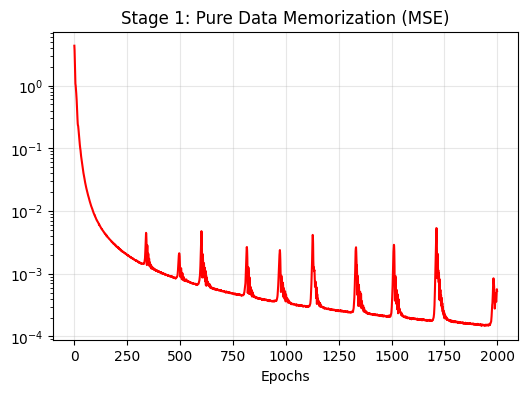

In [ ]:
# ==============================================================================
# STAGE 1: PURE DATA-LOSS MEMORIZATION CHECK (128 SAMPLES)
# ==============================================================================
import os
import pickle

STAGE1_FILENAME = "darcy_flow_stage1.pkl"

# Restructure training targets to Shape: (N_points, n_train)
u_train_all = jnp.array(all_u_flat[:n_train, :, 0].T)

@jax.jit
def compute_pure_data_loss(params_dict, x_grid, y_grid, u_targets):
    F = f_spatial_vmap(params_dict['backbone'], x_grid, y_grid)
    U_pred = F @ params_dict['heads']
    return jnp.mean((U_pred - u_targets) ** 2)

loss_grad_fn_stage1 = jax.jit(value_and_grad(compute_pure_data_loss, argnums=0))

if os.path.exists(STAGE1_FILENAME):
    print(f"--- Loading Stage 1 weights from '{STAGE1_FILENAME}' ---")
    with open(STAGE1_FILENAME, 'rb') as f:
        numpy_params = pickle.load(f)
    params_stage1 = tree_map(lambda x: jnp.array(x), numpy_params)
    
    # Quick eval to confirm it loaded correctly
    full_loss = compute_pure_data_loss(params_stage1, x, y, u_train_all)
    print(f"Loaded Model Pure Data MSE (128 samples): {full_loss:.4e}")

else:
    print(f"--- STAGE 1: Memorizing {n_train} Samples with Pure Data Loss ---")
    key, subkey = jax.random.split(key)
    W_heads = jax.random.normal(subkey, (total_features, n_train)) * 0.01 
    
    params_stage1 = {'backbone': initial_params, 'heads': W_heads}
    optimizer_stage1 = optax.adamw(learning_rate=1e-3, weight_decay=1e-5)
    opt_state_stage1 = optimizer_stage1.init(params_stage1)

    @jax.jit
    def update_stage1(params_dict, opt_state, x_grid, y_grid, u_targets):
        loss, grads = loss_grad_fn_stage1(params_dict, x_grid, y_grid, u_targets)
        updates, opt_state = optimizer_stage1.update(grads, opt_state, params=params_dict)
        return optax.apply_updates(params_dict, updates), opt_state, loss

    epochs_stage1 = 2000
    spatial_batch_size = 5000
    history_data_stage1 = []

    for epoch in tqdm(range(epochs_stage1), desc="Data-Loss Training"):
        rng, shuffle_key = jax.random.split(jax.random.PRNGKey(epoch))
        spatial_idx = jax.random.choice(shuffle_key, total_valid_points, shape=(spatial_batch_size,), replace=False)
        
        x_chunk, y_chunk = x[spatial_idx], y[spatial_idx]
        u_chunk = u_train_all[spatial_idx, :]
        
        params_stage1, opt_state_stage1, loss_val = update_stage1(
            params_stage1, opt_state_stage1, x_chunk, y_chunk, u_chunk
        )
        history_data_stage1.append(float(loss_val))
        
        if (epoch + 1) % 200 == 0:
            full_loss = compute_pure_data_loss(params_stage1, x, y, u_train_all)
            print(f"Epoch {epoch+1:04d} | Pure Data MSE (128 samples): {full_loss:.4e}")

    # Save immediately after training
    numpy_params_s1 = tree_map(lambda x: np.array(x), params_stage1)
    with open(STAGE1_FILENAME, 'wb') as f:
        pickle.dump(numpy_params_s1, f)
    print(f"Saved Stage 1 model to '{STAGE1_FILENAME}'")

    plt.figure(figsize=(6, 4))
    plt.plot(history_data_stage1, color='red')
    plt.yscale('log')
    plt.title("Stage 1: Pure Data Memorization (MSE)")
    plt.xlabel("Epochs")
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
import pickle
import numpy as np
from jax.tree_util import tree_map

def save_weights(params, filename):
    numpy_params = tree_map(lambda x: np.array(x), params)
    with open(filename, 'wb') as f:
        pickle.dump(numpy_params, f)
    print(f"Weights successfully saved to '{filename}'")

# Save Stage 1 (Backbone + 128 Heads)
if 'params_stage1' in locals():
    save_weights(params_stage1, "darcy_flow_stage1.pkl")

Weights successfully saved to 'darcy_flow_stage1.pkl'
Weights successfully saved to 'darcy_flow_stage3_mlp.pkl'


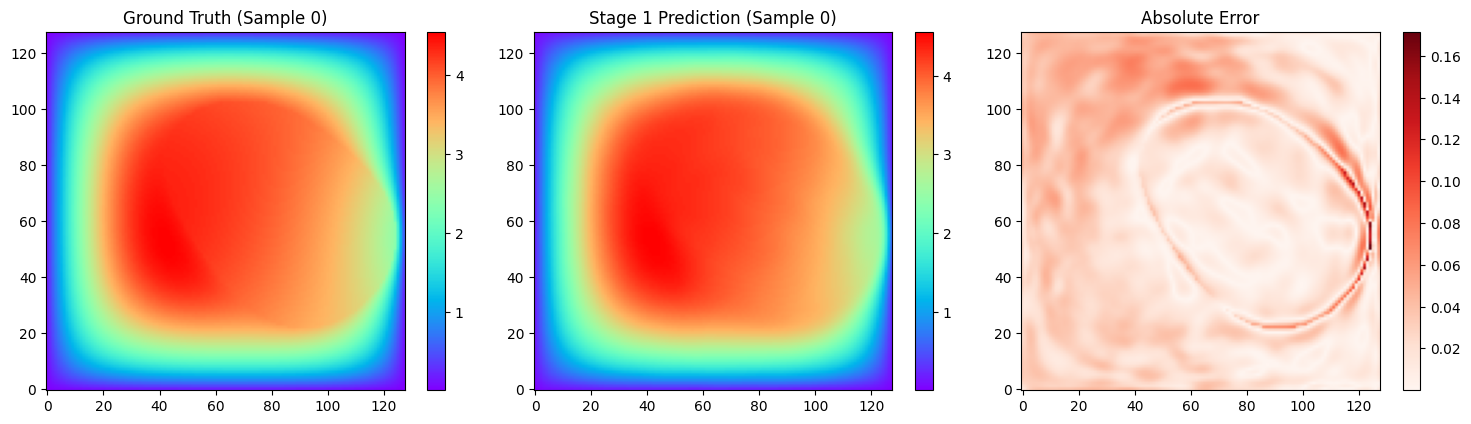

In [6]:
# Pick any sample index from 0 to 127
sample_idx = 0 

# 1. Get the feature evaluations for the full spatial grid
f_eval_stage1 = f_spatial_vmap(params_stage1['backbone'], x, y)

# 2. Multiply by the specific head column for this sample
u_pred_sample = (f_eval_stage1 @ params_stage1['heads'][:, sample_idx]).reshape(fine_nx, fine_ny).T

# 3. Get the corresponding ground truth
u_true_sample = u_train_all[:, sample_idx].reshape(fine_nx, fine_ny).T

# 4. Plot Ground Truth vs Prediction vs Error
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
im0 = axes[0].imshow(u_true_sample, origin='lower', cmap='rainbow')
axes[0].set_title(f"Ground Truth (Sample {sample_idx})")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(u_pred_sample, origin='lower', cmap='rainbow')
axes[1].set_title(f"Stage 1 Prediction (Sample {sample_idx})")
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(jnp.abs(u_true_sample - u_pred_sample), origin='lower', cmap='Reds')
axes[2].set_title("Absolute Error")
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()


--- STAGE 2: Evaluating 1-Shot Physics Solve on Frozen Data Backbone ---
Train Set 1-Shot PDE Solve Data MSE: 1.3321e+00
Test Set  1-Shot PDE Solve Data MSE: 1.1759e+00


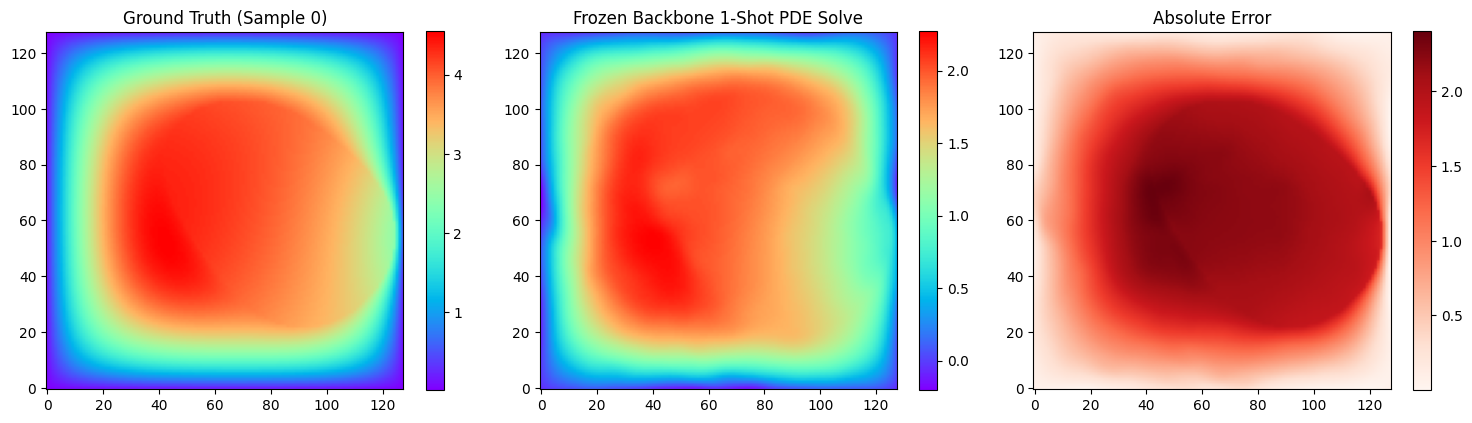

In [16]:
# ==============================================================================
# STAGE 2: FROZEN BACKBONE + 1-SHOT PDE LINEAR SOLVE (BATCHED FIX)
# ==============================================================================
print("\n--- STAGE 2: Evaluating 1-Shot Physics Solve on Frozen Data Backbone ---")
frozen_params = params_stage1['backbone']

@jax.jit
def fast_eval_step(params, w_batch, x_grid, y_grid, u_batch):
    f_eval = f_spatial_vmap(params, x_grid, y_grid)
    u_pred_batch = jnp.matmul(f_eval, w_batch)
    return jnp.mean((u_pred_batch - u_batch)**2)

def evaluate_1shot_solve(dataloader, params_bb):
    total_mse = 0.0
    total_samples = 0
    
    # Subsample spatial grid to prevent OOM during A matrix assembly, 
    # mirroring your original evaluate_dataset function logic
    rng = jax.random.PRNGKey(42)
    spatial_idx = jax.random.choice(rng, jnp.arange(total_valid_points), shape=(5000,), replace=False)
    x_colloc, y_colloc = x[spatial_idx], y[spatial_idx]
    
    for a_batch, ax_batch, ay_batch, u_batch in dataloader:
        # 1. Solve for w using the spatial collocation subset
        w_batch = update_direct_solve_batch(
            params_bb, x_colloc, y_colloc, 
            a_batch[:, spatial_idx, :], ax_batch[:, spatial_idx, :], ay_batch[:, spatial_idx, :],
            x_bc, y_bc, bc_val_array, total_features, chunk_size
        )
        
        # 2. Evaluate MSE over the FULL grid
        batch_mse = fast_eval_step(params_bb, w_batch, x, y, u_batch)
        total_mse += batch_mse.item() * a_batch.shape[0]
        total_samples += a_batch.shape[0]
        
    return total_mse / total_samples

train_pde_mse = evaluate_1shot_solve(train_dataloader, frozen_params)
test_pde_mse = evaluate_1shot_solve(test_dataloader, frozen_params)

print(f"Train Set 1-Shot PDE Solve Data MSE: {train_pde_mse:.4e}")
print(f"Test Set  1-Shot PDE Solve Data MSE: {test_pde_mse:.4e}")

# --- Visualizing Sample 0 Prediction vs Ground Truth ---
# Grab just one batch to prevent memory spikes during visualization
a_raw, ax_raw, ay_raw, u_raw = train_dataset[0]

# Expand dimensions to create a batch of size 1 (1, N_points, 1)
a_batch = a_raw[None, ...]
ax_batch = ax_raw[None, ...]
ay_batch = ay_raw[None, ...]
u_batch = u_raw[None, ...]

sample_idx = 0

# Solve for this specific batch
rng = jax.random.PRNGKey(42)
spatial_idx = jax.random.choice(rng, jnp.arange(total_valid_points), shape=(1000,), replace=False)
w_viz_batch = update_direct_solve_batch(
    frozen_params, x[spatial_idx], y[spatial_idx], 
    a_batch[:, spatial_idx, :], ax_batch[:, spatial_idx, :], ay_batch[:, spatial_idx, :],
    x_bc, y_bc, bc_val_array, total_features, chunk_size
)

# Predict full grid for Sample 0
f_eval_frozen = f_spatial_vmap(frozen_params, x, y)
u_pred_sample0 = (f_eval_frozen @ w_viz_batch[sample_idx]).reshape(fine_nx, fine_ny).T
u_true_sample0 = u_batch[sample_idx].reshape(fine_nx, fine_ny).T

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
im0 = axes[0].imshow(u_true_sample0, origin='lower', cmap='rainbow')
axes[0].set_title("Ground Truth (Sample 0)")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(u_pred_sample0, origin='lower', cmap='rainbow')
axes[1].set_title("Frozen Backbone 1-Shot PDE Solve")
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(jnp.abs(u_true_sample0 - u_pred_sample0), origin='lower', cmap='Reds')
axes[2].set_title("Absolute Error")
fig.colorbar(im2, ax=axes[2])
plt.tight_layout()
plt.show()


--- STAGE 3: Fine-Tuning Backbone with Pure Physics (PDE + BC) Loss ---


Physics Fine-Tuning:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 010 | Train PDE: 2.258e+01 | Train BC: 3.178e-02 | Train Data MSE: 9.727e-01
Epoch 020 | Train PDE: 2.037e+01 | Train BC: 2.778e-02 | Train Data MSE: 8.707e-01
Epoch 030 | Train PDE: 1.916e+01 | Train BC: 2.521e-02 | Train Data MSE: 8.045e-01
Epoch 040 | Train PDE: 1.830e+01 | Train BC: 2.349e-02 | Train Data MSE: 7.559e-01
Epoch 050 | Train PDE: 1.763e+01 | Train BC: 2.245e-02 | Train Data MSE: 7.369e-01
Epoch 060 | Train PDE: 1.693e+01 | Train BC: 2.166e-02 | Train Data MSE: 6.740e-01
Epoch 070 | Train PDE: 1.638e+01 | Train BC: 2.116e-02 | Train Data MSE: 6.673e-01
Epoch 080 | Train PDE: 1.640e+01 | Train BC: 2.160e-02 | Train Data MSE: 6.584e-01
Epoch 090 | Train PDE: 1.608e+01 | Train BC: 2.116e-02 | Train Data MSE: 6.437e-01
Epoch 100 | Train PDE: 1.623e+01 | Train BC: 2.086e-02 | Train Data MSE: 6.534e-01


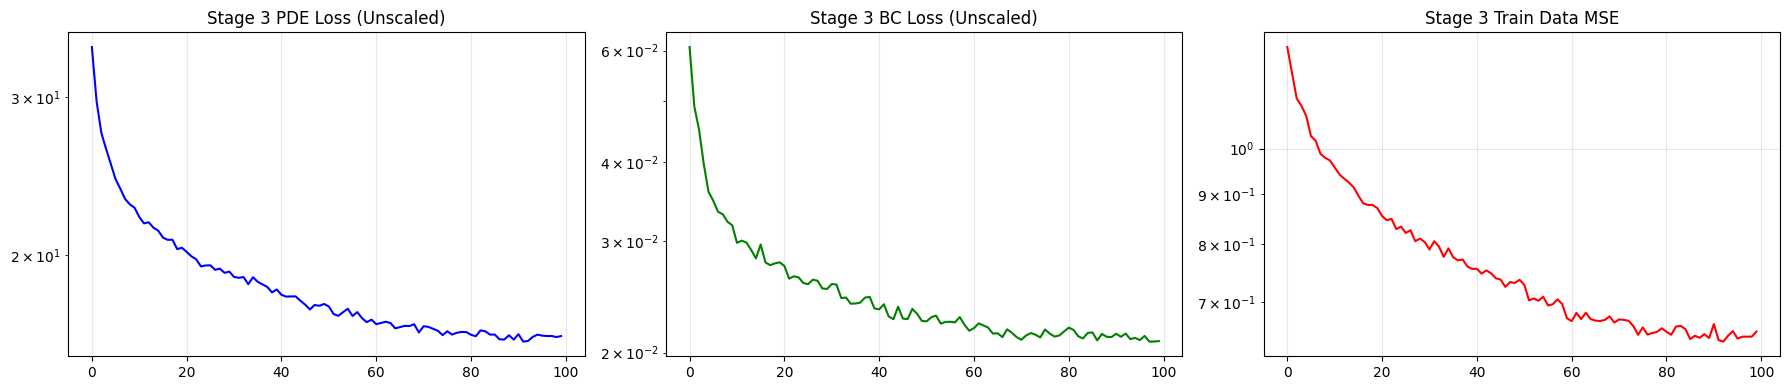

In [ ]:
# ==============================================================================
# STAGE 3: FINE-TUNE BACKBONE WITH PURE PDE + BC LOSS
# ==============================================================================
STAGE3_FILENAME = "darcy_flow_stage3_mlp.pkl"

if os.path.exists(STAGE3_FILENAME):
    print(f"\n--- Loading Stage 3 weights from '{STAGE3_FILENAME}' ---")
    with open(STAGE3_FILENAME, 'rb') as f:
        numpy_params = pickle.load(f)
    params_stage3 = tree_map(lambda x: jnp.array(x), numpy_params)
    
else:
    print("\n--- STAGE 3: Fine-Tuning Backbone with Pure Physics (PDE + BC) Loss ---")
    
    def compute_loss_single(params, w_current, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch):
        u_x, u_y, u_xx, u_yy = u_dir_spatial_vmap(params, x_batch, y_batch, w_current)
        laplacian_u = u_xx + u_yy
        pde_residual = -(a_x_batch * u_x + a_y_batch * u_y + a_batch * laplacian_u) - beta
        f_bc_vals = f_spatial_vmap(params, x_bc, y_bc)
        u_bc_pred = jnp.dot(f_bc_vals, w_current)
        f_interior = f_spatial_vmap(params, x_batch, y_batch)
        u_pred_interior = jnp.dot(f_interior, w_current)
        
        loss_pde_unscaled = jnp.mean(pde_residual ** 2)
        loss_bc_unscaled = jnp.mean((u_bc_pred - bc_val_arr) ** 2)
        loss_data_unscaled = jnp.mean((u_pred_interior - u_batch) ** 2)
        
        loss_pde_scaled = loss_pde_unscaled * pde_loss_weight
        loss_bc_scaled = loss_bc_unscaled * bc_loss_weight
        loss_data_scaled = loss_data_unscaled * data_loss_weight 
        
        return (loss_pde_scaled, loss_bc_scaled, loss_data_scaled), (loss_pde_unscaled, loss_bc_unscaled, loss_data_unscaled)

    batched_compute_loss = jax.vmap(compute_loss_single, in_axes=(None, 0, None, None, 0, 0, 0, None, None, None, 0))

    def compute_pde_bc_losses(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch, total_features, chunk_size):
        w_batch = update_direct_solve_batch(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size)
        scaled_tup, unscaled_tup = batched_compute_loss(params, w_batch, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch)
        l_pde_scaled, l_bc_scaled, l_data_scaled = jnp.mean(scaled_tup[0]), jnp.mean(scaled_tup[1]), jnp.mean(scaled_tup[2])
        
        loss_components = jnp.stack([l_pde_scaled, l_bc_scaled])
        primals_scaled = (l_pde_scaled, l_bc_scaled, l_data_scaled)
        aux_unscaled = (jnp.mean(unscaled_tup[0]), jnp.mean(unscaled_tup[1]), jnp.mean(unscaled_tup[2]))
        return loss_components, (primals_scaled, aux_unscaled)

    loss_jac_fn = jax.jit(jax.jacrev(compute_pde_bc_losses, argnums=0, has_aux=True), static_argnames=['total_features', 'chunk_size'])

    total_steps_s3 = 100 * len(train_dataloader)
    lr_schedule_s3 = optax.cosine_decay_schedule(init_value=1e-4, decay_steps=total_steps_s3, alpha=0.01)
    optimizer_s3 = optax.adamw(learning_rate=lr_schedule_s3, weight_decay=1e-4)

    # Start Stage 3 from the Frozen Backbone
    params_stage3 = frozen_params
    opt_state_stage3 = optimizer_s3.init(params_stage3)

    @jax.jit(static_argnames=['total_features', 'chunk_size'])
    def update_network_stage3(params, opt_state, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch, total_features, chunk_size):
        jac_grads, (primals_scaled, aux_unscaled) = loss_jac_fn(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch, total_features, chunk_size)
        total_grads = tree_map(lambda x: jnp.sum(x, axis=0), jac_grads)
        updates, opt_state = optimizer_s3.update(total_grads, opt_state, params=params)
        return optax.apply_updates(params, updates), opt_state, primals_scaled, aux_unscaled

    epochs_stage3 = 100
    history_pde_s3, history_bc_s3, history_data_s3 = [], [], []

    for epoch in tqdm(range(epochs_stage3), desc="Physics Fine-Tuning"):
        ep_pde, ep_bc, ep_data, num_batches = 0.0, 0.0, 0.0, 0
        
        for a_batch, a_x_batch, a_y_batch, u_batch in train_dataloader:
            rng, pde_key, bc_key = jax.random.split(jax.random.PRNGKey(epoch + num_batches), 3)
            spatial_idx = jax.random.choice(pde_key, total_valid_points, shape=(5000,), replace=False)
            bc_idx = jax.random.choice(bc_key, x_bc.shape[0], shape=(512,), replace=False)
            
            params_stage3, opt_state_stage3, primals, unscaled = update_network_stage3(
                params_stage3, opt_state_stage3, 
                x[spatial_idx], y[spatial_idx],
                a_batch[:, spatial_idx, :], a_x_batch[:, spatial_idx, :], a_y_batch[:, spatial_idx, :],
                x_bc[bc_idx], y_bc[bc_idx], bc_val_array[bc_idx], 
                u_batch[:, spatial_idx, :], total_features, chunk_size
            )
            ep_pde += unscaled[0]
            ep_bc += unscaled[1]
            ep_data += unscaled[2]
            num_batches += 1
            
        history_pde_s3.append(float(ep_pde / num_batches))
        history_bc_s3.append(float(ep_bc / num_batches))
        history_data_s3.append(float(ep_data / num_batches))
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:03d} | Train PDE: {history_pde_s3[-1]:.3e} | Train BC: {history_bc_s3[-1]:.3e} | Train Data MSE: {history_data_s3[-1]:.3e}")

    # Save immediately after training
    numpy_params_s3 = tree_map(lambda x: np.array(x), params_stage3)
    with open(STAGE3_FILENAME, 'wb') as f:
        pickle.dump(numpy_params_s3, f)
    print(f"Saved Stage 3 model to '{STAGE3_FILENAME}'")

    # Plotting Stage 3 Progress
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].plot(history_pde_s3, color='blue')
    axes[0].set_title("Stage 3 PDE Loss (Unscaled)")
    axes[0].set_yscale('log')

    axes[1].plot(history_bc_s3, color='green')
    axes[1].set_title("Stage 3 BC Loss (Unscaled)")
    axes[1].set_yscale('log')

    axes[2].plot(history_data_s3, color='red')
    axes[2].set_title("Stage 3 Train Data MSE")
    axes[2].set_yscale('log')

    for ax in axes: ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# Save Stage 3 (Fine-tuned Backbone)
if 'params_stage3' in locals():
    save_weights(params_stage3, "darcy_flow_stage3_mlp.pkl")

Weights successfully saved to 'darcy_flow_stage3_mlp.pkl'



--- Running Final Evaluation: Train vs Eval Sample Comparison ---
Train Sample Relative L2 Error : 36.62%
Eval  Sample Relative L2 Error : 52.23%


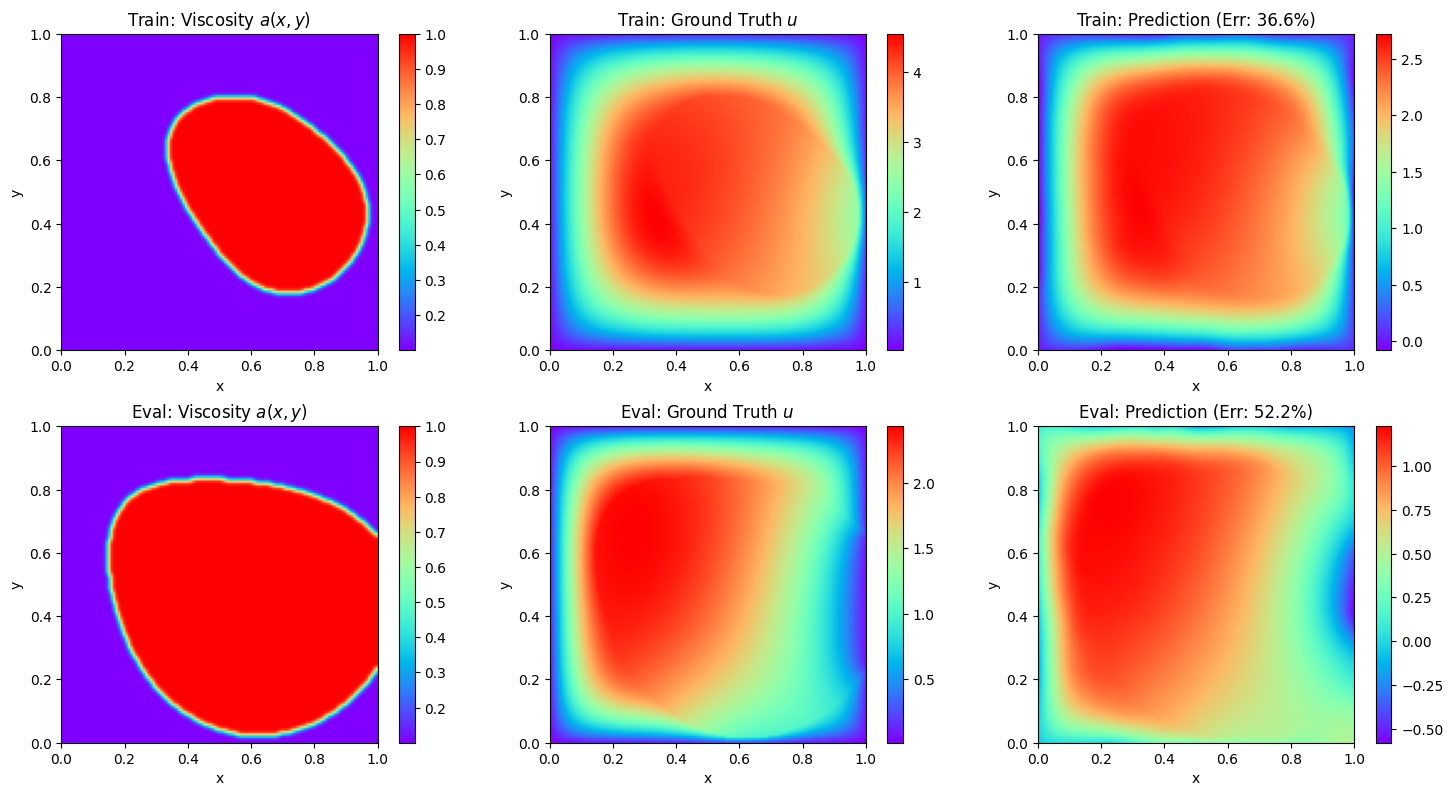

In [19]:
# ==============================================================================
# FINAL CELL: VISUAL AND QUANTITATIVE CHECK (TRAIN VS EVAL)
# ==============================================================================
print("\n--- Running Final Evaluation: Train vs Eval Sample Comparison ---")

# 1. Grab the exact 0th sample from the un-shuffled Train dataset
tr_a_single, tr_ax_single, tr_ay_single, tr_u_true = train_dataset[0]

# Grab the first sample from the Eval/Val dataloader (unshuffled by default)
val_batch_iter = iter(val_dataloader)
val_a, val_ax, val_ay, val_u = next(val_batch_iter)

val_sample_idx = 0
val_a_single = val_a[val_sample_idx]
val_ax_single = val_ax[val_sample_idx]
val_ay_single = val_ay[val_sample_idx]
val_u_true = val_u[val_sample_idx]

# 2. Build collocation points for the direct solve
rng = jax.random.PRNGKey(42)
spatial_idx = jax.random.choice(rng, jnp.arange(total_valid_points), shape=(5000,), replace=False)
x_colloc, y_colloc = x[spatial_idx], y[spatial_idx]

# Solve for weights w using the final backbone parameters (params_stage3 or frozen_params)
active_params = params_stage3 if 'params_stage3' in locals() else frozen_params

w_tr = update_direct_solve_batch(
    active_params, x_colloc, y_colloc, 
    tr_a_single[spatial_idx, :][None, ...], 
    tr_ax_single[spatial_idx, :][None, ...], 
    tr_ay_single[spatial_idx, :][None, ...],
    x_bc, y_bc, bc_val_array, total_features, chunk_size
)[0]

w_val = update_direct_solve_batch(
    active_params, x_colloc, y_colloc, 
    val_a_single[spatial_idx, :][None, ...], 
    val_ax_single[spatial_idx, :][None, ...], 
    val_ay_single[spatial_idx, :][None, ...],
    x_bc, y_bc, bc_val_array, total_features, chunk_size
)[0]

# 3. Predict over the full grid
f_full = f_spatial_vmap(active_params, x, y)
u_tr_pred = (f_full @ w_tr).reshape(fine_nx, fine_ny).T
u_val_pred = (f_full @ w_val).reshape(fine_nx, fine_ny).T

tr_u_plot = tr_u_true.reshape(fine_nx, fine_ny).T
val_u_plot = val_u_true.reshape(fine_nx, fine_ny).T

# 4. Compute Relative L2 Errors
err_tr = jnp.linalg.norm(u_tr_pred.flatten() - tr_u_plot.flatten()) / jnp.linalg.norm(tr_u_plot.flatten())
err_val = jnp.linalg.norm(u_val_pred.flatten() - val_u_plot.flatten()) / jnp.linalg.norm(val_u_plot.flatten())

print(f"Train Sample Relative L2 Error : {err_tr * 100:.2f}%")
print(f"Eval  Sample Relative L2 Error : {err_val * 100:.2f}%")

# 5. Plot Comparison Matrix (2 rows: Train vs Eval)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
ext = [0.0, 1.0, 0.0, 1.0]

# Row 1: Train Sample
im0 = axes[0, 0].imshow(tr_a_single.reshape(fine_nx, fine_ny).T, origin='lower', cmap='rainbow', extent=ext)
axes[0, 0].set_title("Train: Viscosity $a(x,y)$")
fig.colorbar(im0, ax=axes[0, 0])

im1 = axes[0, 1].imshow(tr_u_plot, origin='lower', cmap='rainbow', extent=ext)
axes[0, 1].set_title("Train: Ground Truth $u$")
fig.colorbar(im1, ax=axes[0, 1])

im2 = axes[0, 2].imshow(u_tr_pred, origin='lower', cmap='rainbow', extent=ext)
axes[0, 2].set_title(f"Train: Prediction (Err: {err_tr*100:.1f}%)")
fig.colorbar(im2, ax=axes[0, 2])

# Row 2: Eval Sample
im3 = axes[1, 0].imshow(val_a_single.reshape(fine_nx, fine_ny).T, origin='lower', cmap='rainbow', extent=ext)
axes[1, 0].set_title("Eval: Viscosity $a(x,y)$")
fig.colorbar(im3, ax=axes[1, 0])

im4 = axes[1, 1].imshow(val_u_plot, origin='lower', cmap='rainbow', extent=ext)
axes[1, 1].set_title("Eval: Ground Truth $u$")
fig.colorbar(im4, ax=axes[1, 1])

im5 = axes[1, 2].imshow(u_val_pred, origin='lower', cmap='rainbow', extent=ext)
axes[1, 2].set_title(f"Eval: Prediction (Err: {err_val*100:.1f}%)")
fig.colorbar(im5, ax=axes[1, 2])

for ax_row in axes:
    for ax in ax_row:
        ax.set_xlabel('x')
        ax.set_ylabel('y')

plt.tight_layout()
plt.show()

In [15]:
# ==============================================================================
# LOAD NETWORK WEIGHTS
# ==============================================================================
import pickle
import jax.numpy as jnp
from jax.tree_util import tree_map

def load_weights(filename="darcy_flow_stage3_mlp.pkl"):
    with open(filename, 'rb') as f:
        numpy_params = pickle.load(f)
        
    # Convert standard NumPy arrays back into JAX DeviceArrays
    jax_params = tree_map(lambda x: jnp.array(x), numpy_params)
    print(f"Weights successfully loaded from '{filename}'")
    return jax_params

# Load the parameters back into memory
loaded_params = load_weights(filename="darcy_flow_stage3_mlp.pkl")

# Verify the network structure loaded correctly
print("\nLoaded network structure:")
for layer_name, layer_weights in loaded_params['params'].items():
    if 'kernel' in layer_weights:
        print(f"- {layer_name}: kernel shape {layer_weights['kernel'].shape}")

Weights successfully loaded from 'darcy_flow_stage3_mlp.pkl'

Loaded network structure:
- Dense_0: kernel shape (2048, 512)
- Dense_1: kernel shape (512, 512)
- Dense_2: kernel shape (512, 512)
- Dense_3: kernel shape (512, 512)
